Claude doesnt have the ability to always accurately add datetimes, make certain calculations, set reminders etc. We need to use multiple tools in such cases to be able to get claude to perform a task.  

We want to set up a reminder using claude in this project  
We need three tools for the project ->  
Get current date time - as claude needs to know the current datetime  
Add duration to datetime - as claude is not perfect with datetime addition  
Set a reminder - claude cant do that, thus we need a seperate tool for it.  

In [1]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [3]:
# Helper functions
from anthropic.types import Message

def add_user_message(messages, message):
    user_message = {
        "role": "user", 
        "content": message.content if isinstance(message, Message) else message
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message
    }
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools = None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system
    if tools:
        params["tools"] = tools

    message = client.messages.create(**params)
    return message

def text_from_message(message):
    return "\n".join(
        [block.text for block in message.content if block.type == "text"]
    )

In [4]:
# Tools and Schemas

from datetime import datetime, timedelta


def add_duration_to_datetime(
    datetime_str, duration=0, unit="days", input_format="%Y-%m-%d"
):
    date = datetime.strptime(datetime_str, input_format)

    if unit == "seconds":
        new_date = date + timedelta(seconds=duration)
    elif unit == "minutes":
        new_date = date + timedelta(minutes=duration)
    elif unit == "hours":
        new_date = date + timedelta(hours=duration)
    elif unit == "days":
        new_date = date + timedelta(days=duration)
    elif unit == "weeks":
        new_date = date + timedelta(weeks=duration)
    elif unit == "months":
        month = date.month + duration
        year = date.year + month // 12
        month = month % 12
        if month == 0:
            month = 12
            year -= 1
        day = min(
            date.day,
            [
                31,
                29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                31,
                30,
                31,
                30,
                31,
                31,
                30,
                31,
                30,
                31,
            ][month - 1],
        )
        new_date = date.replace(year=year, month=month, day=day)
    elif unit == "years":
        new_date = date.replace(year=date.year + duration)
    else:
        raise ValueError(f"Unsupported time unit: {unit}")

    return new_date.strftime("%A, %B %d, %Y %I:%M:%S %p")


def set_reminder(content, timestamp):
    print(f"----\nSetting the following reminder for {timestamp}:\n{content}\n----")


add_duration_to_datetime_schema = {
    "name": "add_duration_to_datetime",
    "description": "Adds a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
    "input_schema": {
        "type": "object",
        "properties": {
            "datetime_str": {
                "type": "string",
                "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
            },
            "duration": {
                "type": "number",
                "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
            },
            "unit": {
                "type": "string",
                "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
            },
            "input_format": {
                "type": "string",
                "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
            },
        },
        "required": ["datetime_str"],
    },
}

set_reminder_schema = {
    "name": "set_reminder",
    "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
    "input_schema": {
        "type": "object",
        "properties": {
            "content": {
                "type": "string",
                "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
            },
            "timestamp": {
                "type": "string",
                "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
            },
        },
        "required": ["content", "timestamp"],
    },
}

batch_tool_schema = {
    "name": "batch_tool",
    "description": "Invoke multiple other tool calls simultaneously",
    "input_schema": {
        "type": "object",
        "properties": {
            "invocations": {
                "type": "array",
                "description": "The tool calls to invoke",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The name of the tool to invoke",
                        },
                        "arguments": {
                            "type": "string",
                            "description": "The arguments to the tool, encoded as a JSON string",
                        },
                    },
                    "required": ["name", "arguments"],
                },
            }
        },
        "required": ["invocations"],
    },
}

pass

We create a tool using ToolParam, we generate the schema by passing the get_current_datetime method to claude and get a schema to help us tool call the function

In [5]:
from anthropic.types import ToolParam

def get_current_datetime(date_format = "%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("date_format cannot be empty")
    return datetime.now().strftime(date_format)

get_current_datetime_schema = ToolParam({
    "name": "get_current_datetime",
    "description": "Get the current date and time formatted as a string. Returns the current datetime according to the specified format string.",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
            "type": "string",
            "description": "A strftime-compatible format string that controls the output format (e.g., '%Y-%m-%d %H:%M:%S' returns '2026-03-10 14:30:00'). Must not be empty.",
            "default": "%Y-%m-%d %H:%M:%S"
            }
        },
        "required": []
    }
})

we pass the tools while calling claude

In [5]:
messages = []

messages.append({
    "role": "user",
    "content": "What is the exact time, formatted as HH:MM:SS?"
})

response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema]
)
messages.append(
    {
        "role": "assistant",
        "content": response.content
    }
)
messages

[{'role': 'user', 'content': 'What is the exact time, formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_014VfxL8EXc7M2rjkrayWAir', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]}]

call our tool input the input argument from our response

In [6]:
result = get_current_datetime(**response.content[0].input)

we need to create tool result block and tell it to claude again thus we add another user message again

In [7]:
response

Message(id='msg_011pqBY2hWvgDdtYAEGkXsXs', container=None, content=[ToolUseBlock(id='toolu_014VfxL8EXc7M2rjkrayWAir', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')], model='claude-haiku-4-5-20251001', role='assistant', stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=660, output_tokens=63, server_tool_use=None, service_tier='standard'))

In [8]:
messages.append(
    {
        "role": "user",
        "content": [
            {
                "type": "tool_result",
                "tool_use_id": response.content[0].id,
                "content": result,
                "is_error": False
            }
        ]
    }
)
messages

[{'role': 'user', 'content': 'What is the exact time, formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_014VfxL8EXc7M2rjkrayWAir', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_014VfxL8EXc7M2rjkrayWAir',
    'content': '00:23:51',
    'is_error': False}]}]

In [9]:
client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema] # even though this tool wont be necessary now, but since in the messages there is mention of the tool we have to pass it
)

Message(id='msg_01UBa3YxxjW4g2z93QaUQnpT', container=None, content=[TextBlock(citations=None, text='The exact time is **00:23:51** (in HH:MM:SS format).', type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=740, output_tokens=24, server_tool_use=None, service_tier='standard'))

What happened here?  
we defined a tool schema to help claude understand our tool functions.  
we ask a user message.(we pass details about our tools)  
we get input details to the tool from claude.  
we make the call to the tool on our server.  
add a user message with the response from the tool with the same tool use id.  
send to claude again the entire chat history, to get a final response.

![Screenshot from 2026-03-11 00-27-03.png](<attachment:Screenshot from 2026-03-11 00-27-03.png>)
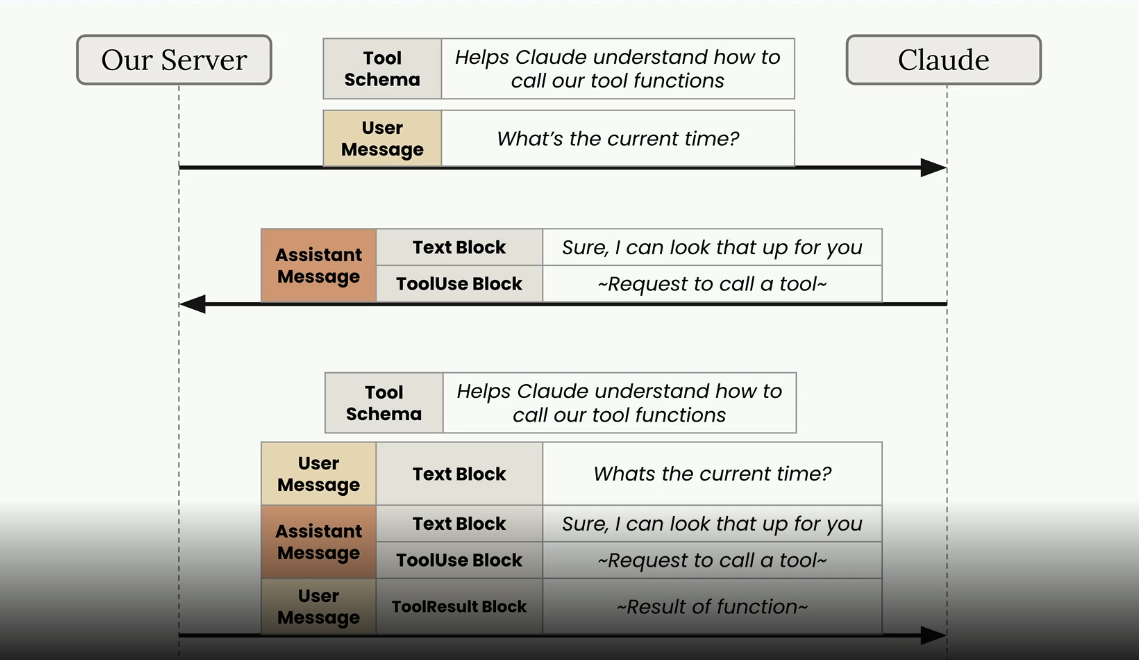

Work on multi turn tool calling

In [11]:
import json

def run_tool(tool_name, tool_input):
    if tool_name == "get_current_datetime":
        return get_current_datetime(**tool_input)
    elif tool_name == "add_duration_to_datetime":
        return add_duration_to_datetime(**tool_input)
    elif tool_name == "set_reminder":
        return set_reminder(**tool_input)

def run_tools(message):
    tool_requests = [
        block for block in message.content if block.type == "tool_use"
    ]

    tool_result_blocks = []

    for tool_request in tool_requests:
        try:
            tool_output = run_tool(tool_request.name, tool_request.input)
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": json.dumps(tool_output),
                "is_error": False
            }
        
            tool_result_blocks.append(tool_result_block)
        except Exception as e:
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": f"Error {e}",
                "is_error": True
            }
    return tool_result_blocks
            

In [9]:
def run_conversation(messages):
    while True:
        response = chat(messages=messages, tools=[
                get_current_datetime_schema,
                add_duration_to_datetime_schema,
                set_reminder_schema
            ]
        )
        add_assistant_message(messages, response)
        print(text_from_message(response))

        if response.stop_reason != "tool_use":
            break

        tool_results = run_tools(response)
        add_user_message(messages, tool_results)

    return messages


In [8]:
messages = []
add_user_message(messages, "What is current time in HH:MM:SS format? Also, give me the time in HH:MM format.")

run_conversation(messages)


The current time is:
- **HH:MM:SS format:** 22:03:22
- **HH:MM format:** 22:03


[{'role': 'user',
  'content': 'What is current time in HH:MM:SS format? Also, give me the time in HH:MM format.'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_019xC3xMvXLMg9Pz8sY22TDA', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use'),
   ToolUseBlock(id='toolu_01SgVorRWmXs3Gxi1Ai3XYLK', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_019xC3xMvXLMg9Pz8sY22TDA',
    'content': '"22:03:22"',
    'is_error': False},
   {'type': 'tool_result',
    'tool_use_id': 'toolu_01SgVorRWmXs3Gxi1Ai3XYLK',
    'content': '"22:03"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='The current time is:\n- **HH:MM:SS format:** 22:03:22\n- **HH:MM format:** 22:03', type='text')]}]

Here in the below output after the first call we see the assistant reply two tool blocks.  
we make the two calls and add a user message with the result of the two function calls.  
Finally the API gives the response.

In [13]:
messages = []
add_user_message(
    messages,
    "Set a reminder for me to visit the doctor, 265 days after Jan 1st 2026."
)

run_conversation(
    messages
)

I'll calculate the date that is 265 days after January 1st, 2026, and then set a reminder for you.
Now I'll set the reminder for that date:
----
Setting the following reminder for 2026-09-23T00:00:00:
Visit the doctor
----
Perfect! I've set a reminder for you to visit the doctor on **Wednesday, September 23, 2026** at 12:00 AM. This is exactly 265 days after January 1st, 2026.


[{'role': 'user',
  'content': 'Set a reminder for me to visit the doctor, 265 days after Jan 1st 2026.'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll calculate the date that is 265 days after January 1st, 2026, and then set a reminder for you.", type='text'),
   ToolUseBlock(id='toolu_014vT1txYGS8aV6cFVNaye9y', caller=DirectCaller(type='direct'), input={'datetime_str': '2026-01-01', 'duration': 265, 'unit': 'days'}, name='add_duration_to_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_014vT1txYGS8aV6cFVNaye9y',
    'content': '"Wednesday, September 23, 2026 12:00:00 AM"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="Now I'll set the reminder for that date:", type='text'),
   ToolUseBlock(id='toolu_01GUZTBudCWszEKUP6CcW7PB', caller=DirectCaller(type='direct'), input={'content': 'Visit the doctor', 'timestamp': '2026-09-23T00:00:00'}, name='set